<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 700; line-height: 1.2;">
        Escalado de Características (Feature Scaling)
      </h1>
      <p style="margin: 6px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Programación para Ciencia de Datos
      </p>
    </td>
    <td style="vertical-align: middle; text-align: right; border: none; padding: 15px 20px; min-width: 240px; font-family: system-ui, -apple-system, sans-serif;">
      <div style="font-size: 0.9em; color: #334155; line-height: 1.5;">
        <strong style="color: #1e3a8a; font-size: 1em;">Especialización en Ciencia de Datos</strong><br>
        <span style="color: #475569; font-weight: 600;">USTA Tunja</span><br><br>
        <b>Santiago A. Zúñiga M.</b><br>
        ✉️ <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
      </div>
    </td>
  </tr>
</table>

---
## Introducción al Feature Scaling

En este cuaderno abordaremos una técnica de preprocesamiento de datos fundamental en Machine Learning: el **Escalado de Características (Feature Scaling)**.

El escalado de características consiste en transformar los valores numéricos de las variables de un dataset para que se encuentren en una escala similar. El propósito es asegurar que todas las características contribuyan de manera equitativa al modelo, evitando que aquellas con valores más grandes dominen el proceso de aprendizaje sobre aquellas con valores más pequeños.

El escalado se vuelve imperativo cuando tratamos con datasets que contienen características con diferentes **rangos**, **unidades de medida** u **órdenes de magnitud**.

---
### 1. Configuración del Entorno 🛠️

Lo primero es cargar las librerías necesarias. Utilizaremos `scikit-learn` para las transformaciones de escalado.

In [14]:
# Módulos base
import pandas as pd
import numpy as np

# Para escalado de características (Feature Scaling)
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Módulos de visualización
import seaborn as sns
import matplotlib.pyplot as plt

# Para comparación con modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Fijamos la semilla aleatoria para que los resultados sean reproducibles
np.random.seed(0)

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


> ⚠️ *Nota: Si encuentras un error de `ModuleNotFoundError` en un entorno local, instala los paquetes con: `!pip install scikit-learn pandas numpy seaborn matplotlib` en una celda de código.*

---
### 2. ¿Por qué necesitamos escalar? El problema de las escalas diferentes 🔍

Para la demostración, crearemos un dataset ficticio de **pacientes con datos clínicos**, donde las características tienen rangos muy diferentes: edad (0-100), colesterol (100-300) y niveles de glucosa (50-400). Veamos qué pasa si un modelo de KNN intenta usarlos sin escalar.

In [15]:
import os
import urllib.request

# --- Resolución de Rutas y Fallback ---
file_path = 'data/hepatitis.csv'
if not os.path.exists(file_path) and os.path.exists(f'05 - Data Preparation/{file_path}'):
    file_path = f'05 - Data Preparation/{file_path}'

if not os.path.exists(file_path):
    print('Descargando dataset...')
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    url = 'https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/05%20-%20Data%20Preparation/data/hepatitis.csv'
    urllib.request.urlretrieve(url, file_path)
# --------------------------------------

# Leemos los datos y trabajamos solo con las columnas numéricas relevantes
hepatitis = pd.read_csv(file_path)

# Imputamos los nulos con la media para poder enfocarnos en el escalado
numeric_cols = hepatitis.select_dtypes(include=np.number).columns
hepatitis[numeric_cols] = hepatitis[numeric_cols].fillna(hepatitis[numeric_cols].mean())

print("Dataset de Hepatitis cargado.")
print(f"Shape: {hepatitis.shape}")
hepatitis[numeric_cols].describe()

Dataset de Hepatitis cargado.
Shape: (155, 20)


,age,bilirubin,alk_phosphate,sgot,albumin,protime
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,41.200000,1.427517,105.325397,85.894040,3.817266,61.852273
std,12.565878,1.188301,46.405585,88.478932,0.616750,17.193528
min,7.000000,0.300000,26.000000,14.000000,2.100000,0.000000
25%,32.000000,0.800000,78.000000,32.500000,3.500000,57.000000
50%,39.000000,1.000000,102.000000,59.000000,3.900000,61.852273
75%,50.000000,1.500000,119.500000,99.000000,4.200000,65.000000
max,78.000000,8.000000,295.000000,648.000000,6.400000,100.000000


Observa cómo las características tienen rangos muy distintos. La columna `sgot` puede llegar a 200+, mientras que `albumin` ronda entre 2 y 5. Sin escalar, el modelo basado en distancia (KNN) dará mucho más peso a `sgot` simplemente por tener valores más grandes, **ignorando efectivamente las otras características**.

#### ¿Cuánto impacta esto en un modelo KNN?
Comparemos el `accuracy` de un clasificador KNN **sin escalar** versus **con escalado**:

In [16]:
# Preparamos los datos: características numéricas y la variable objetivo
X = hepatitis[numeric_cols].values
y = (hepatitis['class'] == 'live').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 1) KNN SIN ESCALAR ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_sin_escalar = accuracy_score(y_test, knn.predict(X_test))

# --- 2) KNN CON StandardScaler ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # ¡Solo fit sobre entrenamiento!
X_test_scaled  = scaler.transform(X_test)        # transform (no fit) sobre prueba

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_con_escalar = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print(f"Accuracy KNN SIN escalado: {acc_sin_escalar:.4f} ({acc_sin_escalar*100:.1f}%)")
print(f"Accuracy KNN CON StandardScaler: {acc_con_escalar:.4f} ({acc_con_escalar*100:.1f}%)")
print(f"\n🚀 Mejora obtenida solo por escalar: {(acc_con_escalar - acc_sin_escalar)*100:.1f} puntos porcentuales")

Accuracy KNN SIN escalado: 0.7742 (77.4%)
Accuracy KNN CON StandardScaler: 0.8065 (80.6%)

🚀 Mejora obtenida solo por escalar: 3.2 puntos porcentuales


---
### 3. Sensibilidad de los Algoritmos al Escalado 🧠

No todos los algoritmos reaccionan igual al escalado:

1. **Algoritmos basados en Descenso de Gradiente (Gradient Descent):**
   - *Ejemplos:* Regresión Logística, Redes Neuronales, SVM con kernel RBF.
   - *Por qué:* El gradiente actualizará los pesos a ritmos muy diferentes si las escalas son muy distintas. Con datos escalados, la convergencia es mucho más rápida y estable.

2. **Algoritmos basados en Distancia:**
   - *Ejemplos:* KNN, K-Means, SVM, PCA.
   - *Por qué:* Calculan distancias geométricas (Euclidiana, Manhattan) entre puntos. Una característica con rango `[0, 10000]` dominará completamente sobre una con rango `[0, 1]`.

3. **Algoritmos basados en Árboles (Tree-Based):**
   - *Ejemplos:* Decision Trees, Random Forest, XGBoost.
   - *Por qué:* **Son insensibles** a la escala. Un árbol solo busca el mejor punto de corte en una sola característica. La escala no afecta los puntos de corte relativos.

---
### 4. Normalización — Min-Max Scaling 📐

La **Normalización (Min-Max Scaling)** transforma los valores para que queden en el rango **[0, 1]**. Es la técnica más intuitiva: el valor mínimo se convierte en 0 y el máximo en 1.

#### Ecuación Matemática

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Donde:
- $X$: Valor original de la observación.
- $X_{min}$: Valor mínimo de la característica en el dataset de **entrenamiento**.
- $X_{max}$: Valor máximo de la característica en el dataset de **entrenamiento**.
- $X_{norm}$: Valor normalizado ∈ [0, 1].

**Cuándo usarla:**
- Cuando la distribución **no es Gaussiana** (no tiene forma de campana).
- Para algoritmos que no asumen una distribución específica (KNN, Redes Neuronales de imágenes).
- Cuando necesitas que los datos estén estrictamente acotados entre 0 y 1.

**Desventaja:** Es muy sensible a **outliers**. Si existe un valor extremo, comprimirá todos los demás valores cerca de 0.

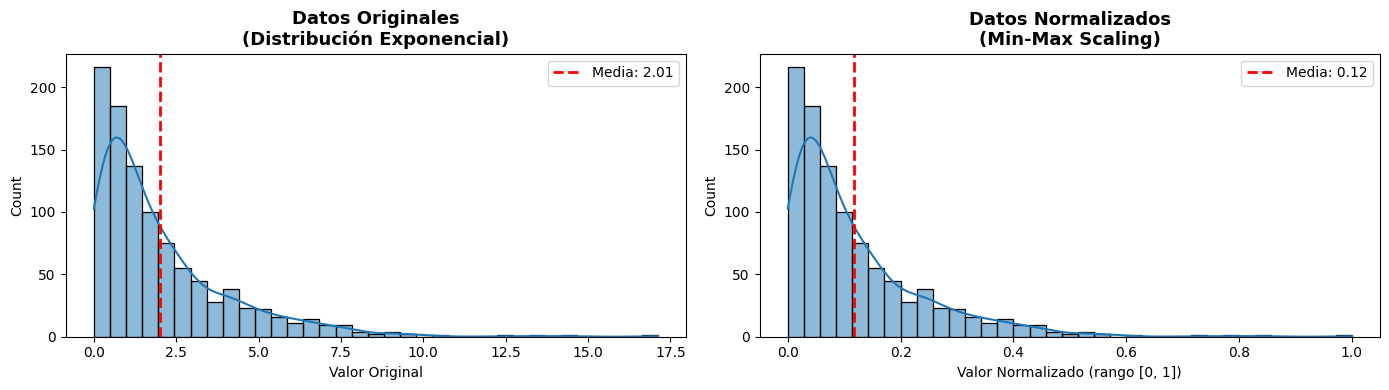


Resumen - Datos Originales:  min=0.001, max=17.122, media=2.007
Resumen - Datos Normalizados: min=0.000, max=1.000, media=0.117


In [17]:
# Generamos 1000 datos de una distribución exponencial (no-Gaussiana) para ilustrar
original_data = np.random.exponential(scale=2.0, size=1000).reshape(-1, 1)

# Inicializamos y ajustamos el MinMaxScaler
norm = MinMaxScaler()
norm.fit(original_data)

# Transformamos los datos
norm_data = norm.transform(original_data)

# Visualizamos la comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(original_data, ax=axes[0], kde=True, color='steelblue', bins=35)
axes[0].set_title("Datos Originales\n(Distribución Exponencial)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Valor Original")
axes[0].axvline(original_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {original_data.mean():.2f}')
axes[0].legend()

sns.histplot(norm_data, ax=axes[1], kde=True, color='salmon', bins=35)
axes[1].set_title("Datos Normalizados\n(Min-Max Scaling)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Valor Normalizado (rango [0, 1])")
axes[1].axvline(norm_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {norm_data.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nResumen - Datos Originales:  min={original_data.min():.3f}, max={original_data.max():.3f}, media={original_data.mean():.3f}")
print(f"Resumen - Datos Normalizados: min={norm_data.min():.3f}, max={norm_data.max():.3f}, media={norm_data.mean():.3f}")

> 🔍 **Observación:** La **forma de la distribución es idéntica** en ambos histogramas — la normalización no cambia la distribución subyacente. Solo comprime el rango del eje X de `[0, ~15]` a `[0, 1]`. Nota cómo la **media también se reescala** proporcionalmente.

---
##### 🛠️ Práctica 1: Normalización Min-Max

---

Tienes un array de precios de casas en miles de dólares: `precios = np.array([150, 250, 300, 450, 500, 800, 1200]).reshape(-1, 1)`.

Aplica **Min-Max Scaling** usando `MinMaxScaler` de scikit-learn. Imprime el array original y el normalizado, y verifica que todos los valores queden entre 0 y 1.

In [18]:
# Escribe tu código aquí



<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
precios = np.array([150, 250, 300, 450, 500, 800, 1200]).reshape(-1, 1)

scaler_mm = MinMaxScaler()
precios_norm = scaler_mm.fit_transform(precios)

print("Precios originales:", precios.flatten())
print("Precios normalizados:", precios_norm.flatten().round(4))

# Verificación
print(f"\nMin: {precios_norm.min():.2f} (debe ser 0.0)")
print(f"Max: {precios_norm.max():.2f} (debe ser 1.0)")
```
</details>

---

#### Aplicando Min-Max Scaling al Dataset de Hepatitis

Ahora aplicamos Min-Max a las columnas numéricas del dataset real de hepatitis. **Recuerda:** el scaler se ajusta (`fit`) solo sobre los datos de entrenamiento.

In [19]:
# Columnas numéricas a escalar (excluimos la variable objetivo que ya es binaria)
cols_to_scale = ['age', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime']
X_numeric = hepatitis[cols_to_scale].copy()

# División train/test
X_train_raw, X_test_raw = train_test_split(X_numeric, test_size=0.2, random_state=0)

# Ajustamos SOLO sobre entrenamiento
minmax = MinMaxScaler()
minmax.fit(X_train_raw)

X_train_mm = pd.DataFrame(minmax.transform(X_train_raw), columns=cols_to_scale)
X_test_mm  = pd.DataFrame(minmax.transform(X_test_raw), columns=cols_to_scale)

print("Estadísticas ANTES de escalar:")
display(X_train_raw.describe().loc[['min','max','mean']].round(2))

print("\nEstadísticas DESPUÉS de normalizar (Min-Max):")
display(X_train_mm.describe().loc[['min','max','mean']].round(4))

Estadísticas ANTES de escalar:


,age,bilirubin,alk_phosphate,sgot,albumin,protime
min,20.00,0.30,26.00,14.00,2.10,0.00
max,78.00,8.00,295.00,528.00,6.40,100.00
mean,41.65,1.44,103.96,85.82,3.82,62.68



Estadísticas DESPUÉS de normalizar (Min-Max):


,age,bilirubin,alk_phosphate,sgot,albumin,protime
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
mean,0.3732,0.1485,0.2898,0.1397,0.3994,0.6268


---
### 5. Estandarización — Z-Score Normalization 📊

La **Estandarización (Z-Score)** transforma los valores para que tengan **media 0** y **desviación estándar 1**. A diferencia de la normalización, **no acota los datos a un rango fijo**, lo que la hace mucho más robusta frente a outliers.

#### Ecuación Matemática

$$X_{std} = \frac{X - \mu}{\sigma}$$

Donde:
- $X$: Valor original de la observación.
- $\mu$: Media (promedio) de la característica calculada sobre el conjunto de **entrenamiento**.
- $\sigma$: Desviación estándar de la característica calculada sobre el conjunto de **entrenamiento**.
- $X_{std}$: Valor estandarizado (Z-Score).

**Cuándo usarla:**
- Cuando la distribución de los datos **es aproximadamente Gaussiana** (forma de campana).
- Para algoritmos que asumen datos centrados en cero: SVM, Regresión Logística, Redes Neuronales, PCA.
- Cuando hay **outliers** (valores extremos) que no queremos que distorsionen la escala.

**Desventaja:** No garantiza un rango específico de valores.

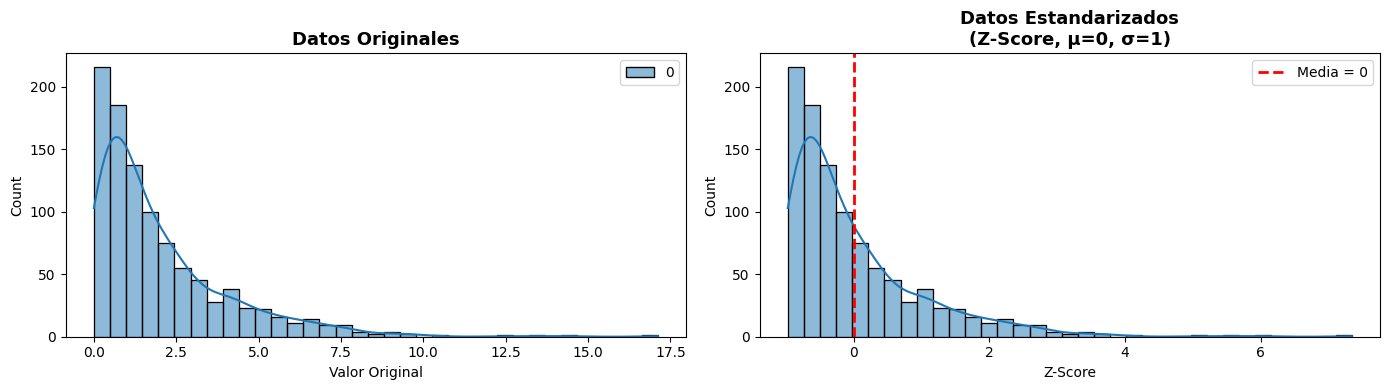


Resumen - Datos Originales:    media=2.007, std=2.058
Resumen - Datos Estandarizados: media=-0.000000 (~0), std=1.000000 (~1)


In [20]:
# Usamos los mismos datos exponenciales para comparar directamente
stand = StandardScaler()
stand.fit(original_data)
stand_data = stand.transform(original_data)

# Visualizamos la comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(original_data, ax=axes[0], kde=True, color='steelblue', bins=35)
axes[0].set_title("Datos Originales", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Valor Original")

sns.histplot(stand_data, ax=axes[1], kde=True, color='mediumseagreen', bins=35)
axes[1].set_title("Datos Estandarizados\n(Z-Score, μ=0, σ=1)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Z-Score")
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Media = 0')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nResumen - Datos Originales:    media={original_data.mean():.3f}, std={original_data.std():.3f}")
print(f"Resumen - Datos Estandarizados: media={stand_data.mean():.6f} (~0), std={stand_data.std():.6f} (~1)")

> 🔍 **Observación:** La **forma de la distribución sigue siendo idéntica**. El eje X ahora está centrado en `0`. Un valor de `2.0` en la escala estandarizada significa que esa observación está **2 desviaciones estándar por encima de la media**. La estandarización NO acota los datos — por eso verás valores negativos y positivos.

---
##### 🛠️ Práctica 2: Estandarización

---

Tienes los siguientes puntajes de un examen: `puntajes = np.array([45, 72, 88, 60, 95, 33, 79, 51]).reshape(-1, 1)`.

Aplica **StandardScaler** para estandarizar los datos. Imprime el array original y el estandarizado. Verifica que la media del array resultante sea aproximadamente **0** y la desviación estándar aproximadamente **1**.

In [21]:
# Escribe tu código aquí



<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
puntajes = np.array([45, 72, 88, 60, 95, 33, 79, 51]).reshape(-1, 1)

scaler_std = StandardScaler()
puntajes_std = scaler_std.fit_transform(puntajes)

print("Puntajes originales:    ", puntajes.flatten())
print("Puntajes estandarizados:", puntajes_std.flatten().round(4))

# Verificación
print(f"\nMedia:             {puntajes_std.mean():.10f} (≈ 0)")
print(f"Desviación estándar: {puntajes_std.std():.10f} (≈ 1)")
```
</details>

---

In [22]:
# Aplicamos StandardScaler al dataset de hepatitis
standard = StandardScaler()
standard.fit(X_train_raw)

X_train_std = pd.DataFrame(standard.transform(X_train_raw), columns=cols_to_scale)
X_test_std  = pd.DataFrame(standard.transform(X_test_raw), columns=cols_to_scale)

print("Estadísticas DESPUÉS de estandarizar (Z-Score):")
display(X_train_std.describe().loc[['mean','std','min','max']].round(4))

Estadísticas DESPUÉS de estandarizar (Z-Score):


,age,bilirubin,alk_phosphate,sgot,albumin,protime
mean,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000
std,1.0041,1.0041,1.0041,1.0041,1.0041,1.0041
min,-1.7489,-0.9240,-1.7000,-0.8900,-2.6422,-3.5467
max,2.9374,5.2985,4.1658,5.4792,3.9734,2.1117


---
### 6. Comparación Visual: Original vs Normalización vs Estandarización 📈

Veamos las tres versiones juntas para una característica del dataset: `bilirubin` (bilirrubina), que tiene una distribución sesgada hacia la derecha.

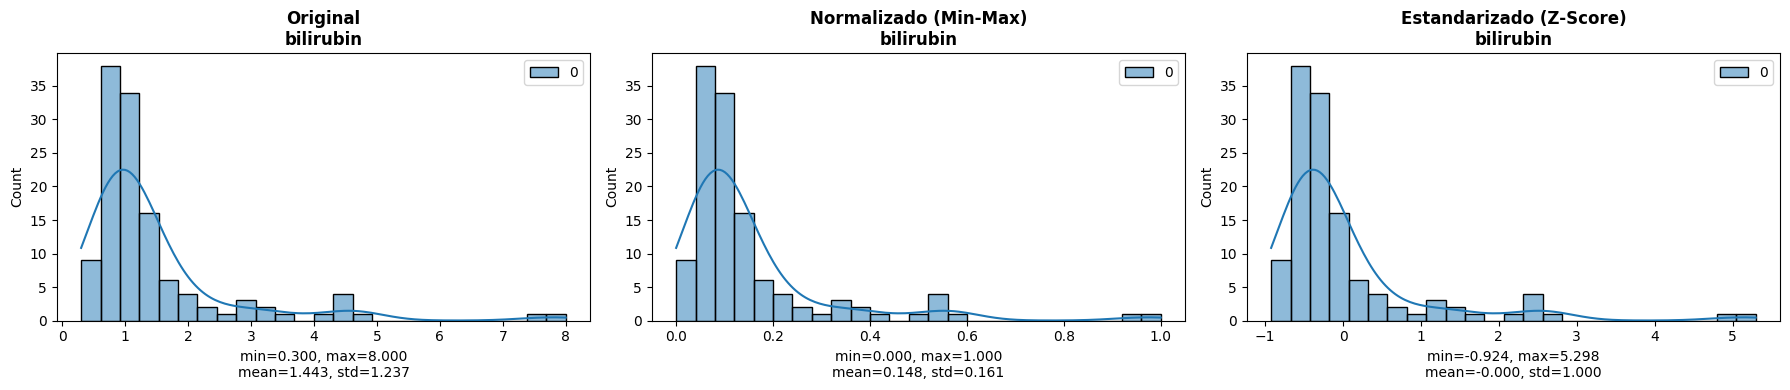

In [23]:
col = 'bilirubin'

# Extraemos solo la columna de interés para la visualización
original = X_train_raw[[col]].values

# Creamos scalers dedicados a UNA sola columna para la comparación visual
# (los scalers minmax y standard fueron ajustados con 6 columnas y no pueden
#  transformar 1 sola columna directamente)
minmax_viz   = MinMaxScaler().fit(original)
standard_viz = StandardScaler().fit(original)

normalizado   = minmax_viz.transform(original)
estandarizado = standard_viz.transform(original)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

titles    = ['Original', 'Normalizado (Min-Max)', 'Estandarizado (Z-Score)']
data_list = [original, normalizado, estandarizado]
colors    = ['steelblue', 'salmon', 'mediumseagreen']

for ax, data, title, color in zip(axes, data_list, titles, colors):
    sns.histplot(data, ax=ax, kde=True, color=color, bins=25)
    ax.set_title(f'{title}\nbilirubin', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'min={data.min():.3f}, max={data.max():.3f}\nmean={data.mean():.3f}, std={data.std():.3f}')

plt.tight_layout()
plt.show()

---
### 7. La Gran Pregunta: ¿Normalizar o Estandarizar? 🤔

Aquí hay una guía práctica basada en las conclusiones de la industria y la literatura científica:

| Característica | Normalización (Min-Max) | Estandarización (Z-Score) |
|---|---|---|
| **Rango de salida** | [0, 1] acotado | Sin límite (−∞ a +∞) |
| **Sensibilidad a outliers** | ⚠️ Alta | ✅ Menor |
| **Distribución asumida** | Ninguna | Aproximadamente Gaussiana |
| **Algoritmos recomendados** | KNN, Redes Neuronales (imágenes), K-Means | SVM, Regresión Logística, PCA, Redes Neuronales |
| **Algoritmos insensibles** | Decision Tree, Random Forest, XGBoost | Decision Tree, Random Forest, XGBoost |

**Conclusiones clave:**
1. **Es un hiperparámetro:** El método de escalado puede mejorar drásticamente el accuracy, incluso con los mejores hiperparámetros del modelo.
2. **Experimenta:** Prueba ambos métodos (y también `RobustScaler` si tienes outliers severos).
3. **PCA requiere escalado:** PCA es un método basado en varianza; **siempre** escala antes de aplicarlo.
4. **Árboles no requieren escalado:** Random Forest, XGBoost, LightGBM no se benefician del escalado monótono.

---
##### 🛠️ Práctica 3: Comparando Métodos de Escalado

---

Usando el dataset de hepatitis ya cargado (`hepatitis`), haz lo siguiente:

1. Selecciona las columnas `['age', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime']` como características (`X`) y la columna `class` transformada a binario (`live` → 1, `die` → 0) como objetivo (`y`).
2. Divide los datos en entrenamiento y prueba (80/20, `random_state=42`).
3. Entrena **tres** clasificadores `KNeighborsClassifier(n_neighbors=7)`:
   - Uno **sin escalar**.
   - Uno con **MinMaxScaler**.
   - Uno con **StandardScaler**.
4. Imprime el `accuracy_score` de cada uno sobre el conjunto de prueba.

¿Cuál método da mejor resultado?

In [24]:
# Escribe tu código aquí



<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
cols = ['age', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime']
X_p3 = hepatitis[cols].values
y_p3 = (hepatitis['class'] == 'live').astype(int).values

X_tr, X_te, y_tr, y_te = train_test_split(X_p3, y_p3, test_size=0.2, random_state=42)

# 1. Sin escalar
knn_raw = KNeighborsClassifier(n_neighbors=7)
knn_raw.fit(X_tr, y_tr)
acc_raw = accuracy_score(y_te, knn_raw.predict(X_te))

# 2. Con MinMaxScaler
mm = MinMaxScaler().fit(X_tr)
knn_mm = KNeighborsClassifier(n_neighbors=7)
knn_mm.fit(mm.transform(X_tr), y_tr)
acc_mm = accuracy_score(y_te, knn_mm.predict(mm.transform(X_te)))

# 3. Con StandardScaler
ss = StandardScaler().fit(X_tr)
knn_ss = KNeighborsClassifier(n_neighbors=7)
knn_ss.fit(ss.transform(X_tr), y_tr)
acc_ss = accuracy_score(y_te, knn_ss.predict(ss.transform(X_te)))

print(f"Accuracy SIN escalar:     {acc_raw:.4f} ({acc_raw*100:.1f}%)")
print(f"Accuracy MinMaxScaler:    {acc_mm:.4f} ({acc_mm*100:.1f}%)")
print(f"Accuracy StandardScaler:  {acc_ss:.4f} ({acc_ss*100:.1f}%)")
```
</details>

---

---
### 8. RobustScaler: Escalado Resistente a Outliers 🛡️

Cuando los datos tienen **outliers severos**, tanto Min-Max (que se ve afectado por el máximo) como Z-Score (que se ve afectado por la media) pueden generar escalados distorsionados. Para estos casos, `RobustScaler` usa la **mediana** y el **rango intercuartílico (IQR)** en lugar de la media y la desviación estándar, siendo mucho más robusto:

$$X_{robust} = \frac{X - Q_2}{Q_3 - Q_1}$$

Donde:
- $Q_1$: Percentil 25 (primer cuartil).
- $Q_2$: Percentil 50 (mediana).
- $Q_3$: Percentil 75 (tercer cuartil).
- $IQR = Q_3 - Q_1$: Rango Intercuartílico.

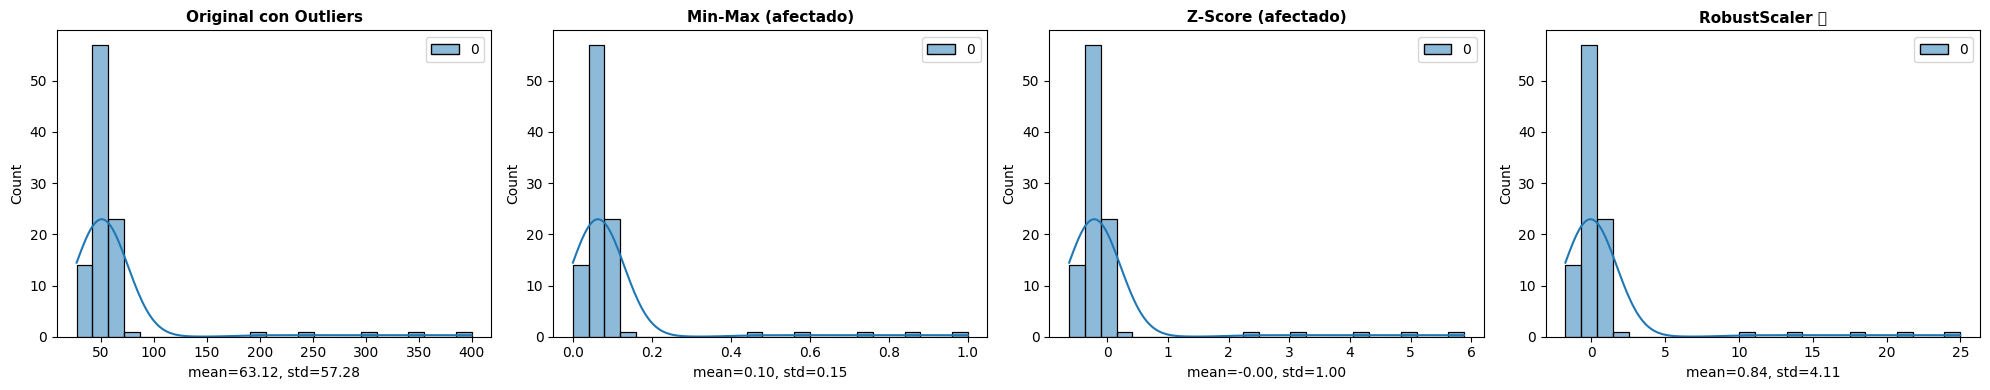

Comparación de escaladores con 5 outliers extremos (200-400) y 95 datos normales (~50):
Original:    min=27,  max=400
Min-Max:     min=0.000, max=1.000  (los datos 'normales' se comprimen en ~0.0-0.27)
Z-Score:     min=-0.631, max=5.882
RobustScale: min=-1.751, max=24.995


In [25]:
# Creamos un dataset con outliers extremos para demostrar la diferencia
np.random.seed(1)
datos_normales = np.random.normal(loc=50, scale=10, size=95)
outliers = np.array([200, 250, 300, 350, 400])  # 5 outliers extremos
datos_con_outliers = np.concatenate([datos_normales, outliers]).reshape(-1, 1)

# Aplicamos los tres scalers
mm_rob = MinMaxScaler().fit_transform(datos_con_outliers)
std_rob = StandardScaler().fit_transform(datos_con_outliers)
robust_rob = RobustScaler().fit_transform(datos_con_outliers)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

datasets = [datos_con_outliers, mm_rob, std_rob, robust_rob]
titles = ['Original con Outliers', 'Min-Max (afectado)', 'Z-Score (afectado)', 'RobustScaler ✅']
colors = ['steelblue', 'salmon', 'mediumseagreen', 'darkorange']

for ax, data, title, color in zip(axes, datasets, titles, colors):
    sns.histplot(data, ax=ax, kde=True, color=color, bins=25)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(f'mean={data.mean():.2f}, std={data.std():.2f}')

plt.tight_layout()
plt.show()

print("Comparación de escaladores con 5 outliers extremos (200-400) y 95 datos normales (~50):")
print(f"Original:    min={datos_con_outliers.min():.0f},  max={datos_con_outliers.max():.0f}")
print(f"Min-Max:     min={mm_rob.min():.3f}, max={mm_rob.max():.3f}  (los datos 'normales' se comprimen en ~0.0-0.27)")
print(f"Z-Score:     min={std_rob.min():.3f}, max={std_rob.max():.3f}")
print(f"RobustScale: min={robust_rob.min():.3f}, max={robust_rob.max():.3f}")

---
### ⚠️ Regla de Oro: Evita la Fuga de Datos (Data Leakage)

<div class="alert alert-block alert-danger" style="background:#fef2f2; border-left:6px solid #dc2626; padding:16px; border-radius:6px; margin:8px 0;">
<b>⚠️ ¡CRÍTICO!</b> Los escaladores <b>SIEMPRE</b> deben ajustarse (<code>.fit()</code> o <code>.fit_transform()</code>) <b>ÚNICAMENTE</b> sobre los datos de <b>entrenamiento</b> (Training set).<br><br>
Luego, el scalers ya ajustado se usa para transformar (<code>.transform()</code>) los datos de prueba (Test set) y validación.<br><br>
<b>¿Por qué?</b> Si ajustas el scaler sobre todo el dataset (incluyendo prueba), el scaler "verá" información del futuro (el mínimo y máximo global, o la media global real). Esto invalida completamente la evaluación del modelo, ya que en producción el scaler no tiene acceso a datos futuros.<br><br>
<b>Nota adicional:</b> Por lo general, <b>no se requiere</b> escalar la variable objetivo ($y$), excepto en algunos casos muy específicos de regresión profunda.
</div>

In [26]:
# ❌ FORMA INCORRECTA (Data Leakage)
X_all = hepatitis[cols_to_scale].values
scaler_malo = StandardScaler()
X_all_scaled_MAL = scaler_malo.fit_transform(X_all)  # ← FIT sobre TODO el dataset
# ... y luego dividir en train/test. ¡Los datos de test ya "contaminaron" el scaler!

# ✅ FORMA CORRECTA
X_train_ok, X_test_ok, _, _ = train_test_split(X_all, np.zeros(len(X_all)), test_size=0.2, random_state=42)

scaler_bueno = StandardScaler()
scaler_bueno.fit(X_train_ok)             # ← FIT solo sobre entrenamiento ✅

X_train_scaled_OK = scaler_bueno.transform(X_train_ok)  # transform entrenamiento
X_test_scaled_OK  = scaler_bueno.transform(X_test_ok)   # transform prueba con los parámetros del train

print("✅ Parámetros del scaler (calculados SOLO sobre entrenamiento):")
print(f"   Medias (primeras 3 cols): {scaler_bueno.mean_[:3].round(3)}")
print(f"   Std   (primeras 3 cols): {scaler_bueno.scale_[:3].round(3)}")
print(f"\n   Shape train escalado: {X_train_scaled_OK.shape}")
print(f"   Shape test  escalado: {X_test_scaled_OK.shape}")

✅ Parámetros del scaler (calculados SOLO sobre entrenamiento):
   Medias (primeras 3 cols): [ 40.839   1.453 107.267]
   Std   (primeras 3 cols): [12.833  1.156 43.975]

   Shape train escalado: (124, 6)
   Shape test  escalado: (31, 6)


---
##### 🛠️ Práctica 4: Evitando la Fuga de Datos

---

Se tiene el siguiente fragmento de código con un error de fuga de datos. Identifica el error y corrígelo:

```python
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X = hepatitis[['age', 'bilirubin', 'sgot', 'albumin']].values
y = (hepatitis['class'] == 'live').astype(int).values

# CÓDIGO CON ERROR:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)           # ← Error aquí
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
```

Escribe la versión corregida en la celda de abajo.

In [27]:
# Escribe el código CORREGIDO aquí



<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X = hepatitis[['age', 'bilirubin', 'sgot', 'albumin']].values
y = (hepatitis['class'] == 'live').astype(int).values

# CÓDIGO CORRECTO:
# 1. PRIMERO dividir en train y test (sin escalar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. LUEGO ajustar el scaler SOLO sobre entrenamiento
scaler = MinMaxScaler()
scaler.fit(X_train)            # ← Solo fit sobre train ✅

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # ← Solo transform sobre test ✅

print("✅ Correcto! El scaler fue ajustado solo con datos de entrenamiento.")
```
</details>

---

---
### 9. Resumen y Guía Rápida de Selección 📋

| Scaler | Ecuación | Rango Salida | Robusto a Outliers | Cuándo usar |
|---|---|---|---|---|
| **MinMaxScaler** | (X−min)/(max−min) | [0, 1] | ❌ No | Datos no-Gaussianos, NN de imágenes, K-Means |
| **StandardScaler** | (X−μ)/σ | (−∞, +∞) | ⚠️ Parcial | SVM, PCA, Regresión Logística, distribuciones ≈ Gaussianas |
| **RobustScaler** | (X−Q₂)/IQR | (−∞, +∞) | ✅ Sí | Datasets con outliers significativos |

**Recomendación general:** Experimenta con todos. El método de escalado es un hiperparámetro más de tu pipeline y puede tener un impacto significativo en el rendimiento del modelo.